<a href="https://colab.research.google.com/github/Vaishnavi-04Patil/cancer-risk-prediction-ml/blob/main/EDA_cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder


In [2]:
df=pd.read_csv('/content/cancer-risk-factors.csv')

In [3]:
df.head(5)

,Patient_ID,Cancer_Type,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,...,Physical_Activity,Air_Pollution,Occupational_Hazards,BRCA_Mutation,H_Pylori_Infection,Calcium_Intake,Overall_Risk_Score,BMI,Physical_Activity_Level,Risk_Level
0,LU0000,Breast,68,0,7,2,8,0,5,3,...,4,6,3,1,0,0,0.398696,28.0,5,Medium
1,LU0001,Prostate,74,1,8,9,8,0,0,3,...,1,3,3,0,0,5,0.424299,25.4,9,Medium
2,LU0002,Skin,55,1,7,10,7,0,3,3,...,1,8,10,0,0,6,0.605082,28.6,2,Medium
3,LU0003,Colon,61,0,6,2,2,0,6,2,...,6,4,8,0,0,8,0.318449,32.1,7,Low
4,LU0004,Lung,67,1,10,7,4,0,6,3,...,9,10,9,0,0,5,0.524358,25.1,2,Medium


In [4]:
df.describe()

,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,Fruit_Veg_Intake,Physical_Activity,Air_Pollution,Occupational_Hazards,BRCA_Mutation,H_Pylori_Infection,Calcium_Intake,Overall_Risk_Score,BMI,Physical_Activity_Level
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.00000,2000.000000,2000.000000,2000.000000
mean,63.248000,0.489000,5.157000,5.035000,5.967500,0.194500,5.189500,4.563500,4.927500,4.015000,5.323000,4.979000,0.032500,0.19650,3.94050,0.454449,26.183350,4.938500
std,10.462946,0.500004,3.325339,3.260996,3.061393,0.395914,3.154452,3.088323,3.045305,2.978458,3.207462,3.212899,0.177368,0.39745,3.04887,0.123074,3.947459,3.166027
min,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.029285,15.000000,0.000000
25%,56.000000,0.000000,2.000000,2.000000,4.000000,0.000000,3.000000,2.000000,3.000000,1.000000,3.000000,2.000000,0.000000,0.00000,1.00000,0.366982,23.500000,2.000000
50%,64.000000,0.000000,5.000000,5.000000,6.000000,0.000000,5.000000,4.000000,5.000000,4.000000,5.000000,5.000000,0.000000,0.00000,4.00000,0.455399,26.200000,5.000000
75%,70.000000,1.000000,8.000000,8.000000,9.000000,0.000000,8.000000,7.000000,8.000000,6.000000,8.000000,8.000000,0.000000,0.00000,6.00000,0.539782,28.700000,8.000000
max,90.000000,1.000000,10.000000,10.000000,10.000000,1.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,1.000000,1.00000,10.00000,0.852158,41.400000,10.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               2000 non-null   object 
 1   Cancer_Type              2000 non-null   object 
 2   Age                      2000 non-null   int64  
 3   Gender                   2000 non-null   int64  
 4   Smoking                  2000 non-null   int64  
 5   Alcohol_Use              2000 non-null   int64  
 6   Obesity                  2000 non-null   int64  
 7   Family_History           2000 non-null   int64  
 8   Diet_Red_Meat            2000 non-null   int64  
 9   Diet_Salted_Processed    2000 non-null   int64  
 10  Fruit_Veg_Intake         2000 non-null   int64  
 11  Physical_Activity        2000 non-null   int64  
 12  Air_Pollution            2000 non-null   int64  
 13  Occupational_Hazards     2000 non-null   int64  
 14  BRCA_Mutation           

Understanding Data by EDA


In [6]:
risk_counts= df['Risk_Level'].value_counts()
print(risk_counts)
risk_percentage = (risk_counts / len(df)) * 100
print(risk_percentage)


Risk_Level
Medium    1574
Low        324
High       102
Name: count, dtype: int64
Risk_Level
Medium    78.7
Low       16.2
High       5.1
Name: count, dtype: float64


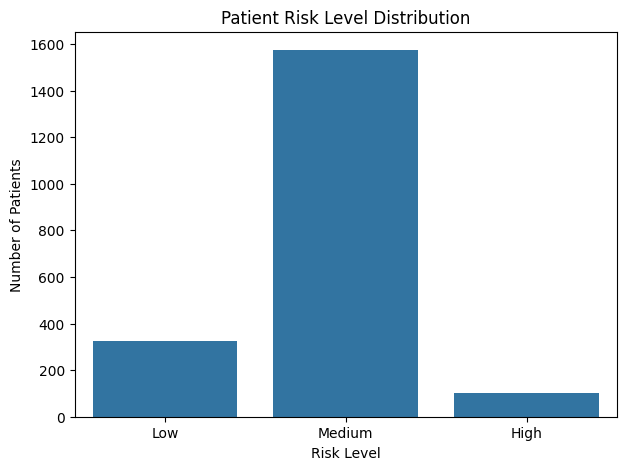

In [7]:
risk_order = ['Low', 'Medium', 'High']
risk_counts = df['Risk_Level'].value_counts().reindex(risk_order)

plt.figure(figsize=(7,5))
sns.barplot(x=risk_counts.index, y=risk_counts.values)

plt.title('Patient Risk Level Distribution')
plt.xlabel('Risk Level')
plt.ylabel('Number of Patients')
plt.show()

data is highly imbalance
Risk_Level


*  Medium    78.7
*  Low       16.2
*  High       5.1








In [8]:
df.Gender.value_counts()

,count
Gender,
0,1022
1,978


<Axes: xlabel='Cancer_Type'>

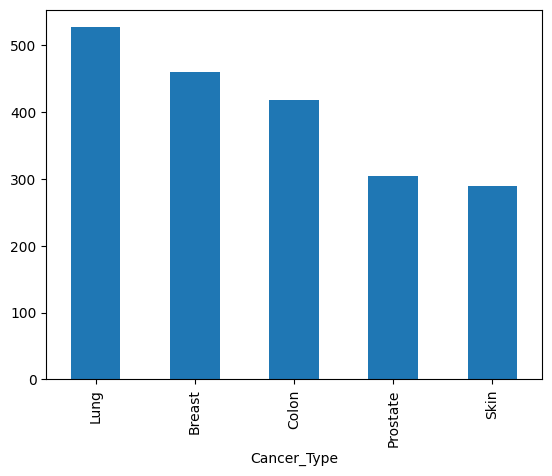

In [9]:
df.Cancer_Type.value_counts().plot(kind='bar')

In [10]:
gender_cancer_count = df.groupby(['Gender', 'Cancer_Type']).size().reset_index(name='Count')

print(gender_cancer_count)
##multivariate analysis


   Gender Cancer_Type  Count
0       0      Breast    455
1       0       Colon    197
2       0        Lung    238
3       0        Skin    132
4       1      Breast      5
5       1       Colon    221
6       1        Lung    289
7       1    Prostate    305
8       1        Skin    158


In [11]:
gender_cancer_count = df.groupby(['Gender', 'Cancer_Type']).size().reset_index(name='Count')

gender_cancer_count['Gender'] = gender_cancer_count['Gender'].map({
    0: 'Female',
    1: 'Male'
})

print(gender_cancer_count)

   Gender Cancer_Type  Count
0  Female      Breast    455
1  Female       Colon    197
2  Female        Lung    238
3  Female        Skin    132
4    Male      Breast      5
5    Male       Colon    221
6    Male        Lung    289
7    Male    Prostate    305
8    Male        Skin    158


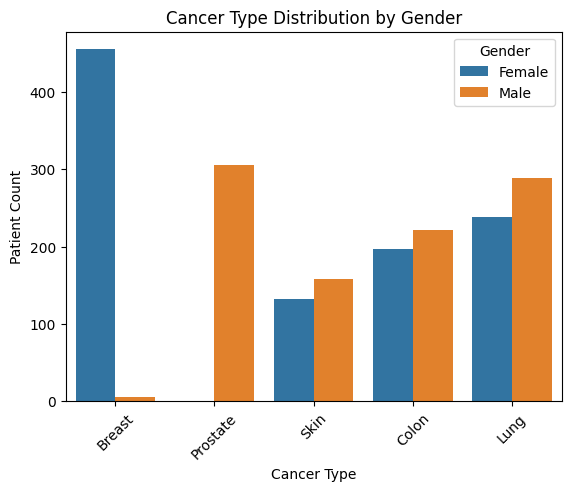

In [12]:
sns.countplot(data=df, x='Cancer_Type', hue='Gender')

plt.title('Cancer Type Distribution by Gender')
plt.xlabel('Cancer Type')
plt.ylabel('Patient Count')
plt.legend(title='Gender', labels=['Female', 'Male'])
plt.xticks(rotation=45)
plt.show()

In [13]:
under_35 = df[df['Age'] < 35]

cancer_count = under_35['Cancer_Type'].value_counts()

print(cancer_count)

Cancer_Type
Lung      6
Breast    2
Skin      1
Name: count, dtype: int64


In [14]:
risk_factors = [
    'Smoking',
    'Alcohol_Use',
    'Obesity',
    'Family_History',
    'Diet_Red_Meat',
    'Diet_Salted_Processed',
    'Fruit_Veg_Intake',
    'Physical_Activity',
    'Air_Pollution',
    'Occupational_Hazards',
    'BRCA_Mutation',
    'H_Pylori_Infection'
]

high_risk = df[df['Risk_Level'] == 'High']

factor_contribution = high_risk[risk_factors].mean().sort_values(ascending=False) * 100

print(factor_contribution.round(2))

Air_Pollution            853.92
Smoking                  751.96
Alcohol_Use              751.96
Diet_Red_Meat            736.27
Obesity                  727.45
Diet_Salted_Processed    703.92
Occupational_Hazards     699.02
Physical_Activity        492.16
Fruit_Veg_Intake         391.18
H_Pylori_Infection        24.51
Family_History            20.59
BRCA_Mutation              4.90
dtype: float64


In [15]:
high = df[df['Risk_Level'] == 'High'][risk_factors].mean()
low = df[df['Risk_Level'] == 'Low'][risk_factors].mean()

comparison = pd.DataFrame({
    'High_Risk_%': high * 100,
    'Low_Risk_%': low * 100,
    'Difference_%': (high - low) * 100
}).sort_values('Difference_%', ascending=False)

print(comparison.round(2))

                       High_Risk_%  Low_Risk_%  Difference_%
Air_Pollution               853.92      294.75        559.17
Smoking                     751.96      284.57        467.39
Alcohol_Use                 751.96      298.46        453.50
Diet_Salted_Processed       703.92      288.89        415.03
Occupational_Hazards        699.02      336.42        362.60
Diet_Red_Meat               736.27      397.22        339.05
Obesity                     727.45      482.41        245.04
Physical_Activity           492.16      366.98        125.18
H_Pylori_Infection           24.51       17.59          6.92
Family_History               20.59       13.89          6.70
BRCA_Mutation                 4.90        3.70          1.20
Fruit_Veg_Intake            391.18      566.67       -175.49


Risk_Level               High     Low  Difference
Air_Pollution          853.92  294.75      559.17
Smoking                751.96  284.57      467.39
Alcohol_Use            751.96  298.46      453.50
Diet_Salted_Processed  703.92  288.89      415.03
Occupational_Hazards   699.02  336.42      362.60
Diet_Red_Meat          736.27  397.22      339.05
Obesity                727.45  482.41      245.04
Physical_Activity      492.16  366.98      125.18
H_Pylori_Infection      24.51   17.59        6.92
Family_History          20.59   13.89        6.70
BRCA_Mutation            4.90    3.70        1.20
Fruit_Veg_Intake       391.18  566.67     -175.49


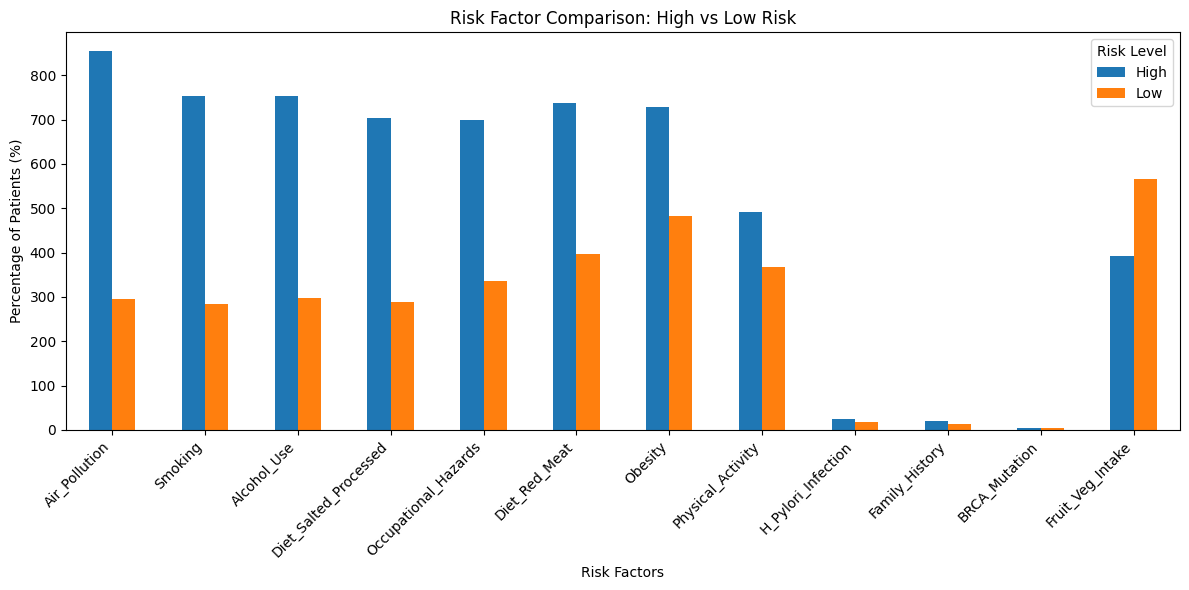

In [16]:
# Select only High and Low risk patients
risk_df = df[df['Risk_Level'].isin(['High', 'Low'])]

# Calculate percentage of patients having each factor within High and Low groups
comparison = risk_df.groupby('Risk_Level')[risk_factors].mean().T * 100

# Difference between High and Low
comparison['Difference'] = comparison['High'] - comparison['Low']

# Sort by largest difference
comparison = comparison.sort_values('Difference', ascending=False)

print(comparison.round(2))

# Bar chart: High vs Low
comparison[['High', 'Low']].plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Risk Factor Comparison: High vs Low Risk')
plt.xlabel('Risk Factors')
plt.ylabel('Percentage of Patients (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Risk Level')
plt.tight_layout()
plt.show()

            count   mean  median   min   max
Risk_Level                                  
High          102  26.23   26.45  15.5  35.3
Low           324  25.81   25.80  15.0  36.3
Medium       1574  26.26   26.20  15.0  41.4


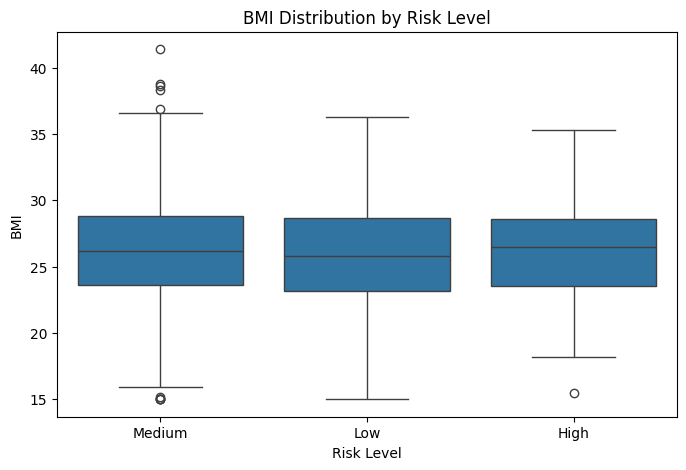

In [17]:
# Average BMI by Risk Level
bmi_by_risk = df.groupby('Risk_Level')['BMI'].agg(
    ['count', 'mean', 'median', 'min', 'max']
)

print(bmi_by_risk.round(2))

# Boxplot: BMI distribution by Risk Level
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Risk_Level',
    y='BMI'
)

plt.title('BMI Distribution by Risk Level')
plt.xlabel('Risk Level')
plt.ylabel('BMI')

plt.show()

            count   mean  median
Risk_Level                      
High          102  26.23   26.45
Low           324  25.81   25.80


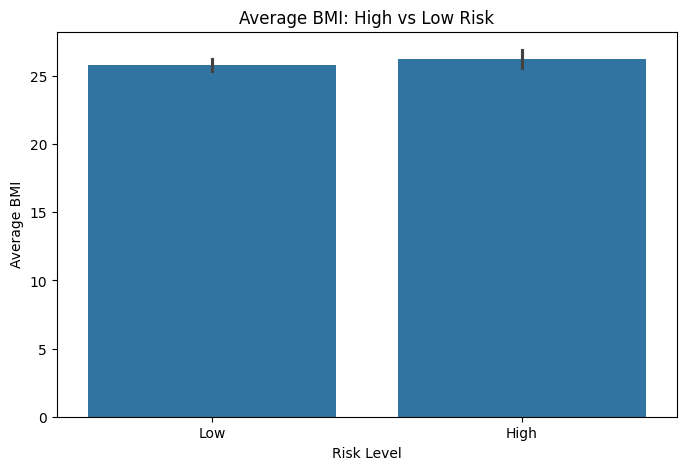

In [18]:
bmi_high_low = df[df['Risk_Level'].isin(['High', 'Low'])]

print(
    bmi_high_low.groupby('Risk_Level')['BMI']
    .agg(['count', 'mean', 'median'])
    .round(2)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=bmi_high_low,
    x='Risk_Level',
    y='BMI',
    estimator='mean'
)

plt.title('Average BMI: High vs Low Risk')
plt.xlabel('Risk Level')
plt.ylabel('Average BMI')

plt.show()

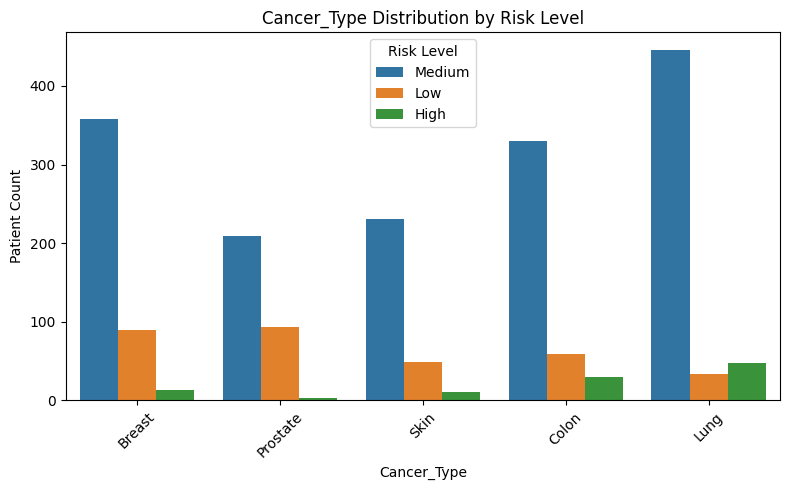

In [19]:
# Drop Patient_ID and Risk_Level
categorical_cols = df.drop(columns=['Patient_ID', 'Risk_Level']).select_dtypes(
    include=['object', 'category']
).columns

# Count plots
for col in categorical_cols:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x=col, hue='Risk_Level')

    plt.title(f'{col} Distribution by Risk Level')
    plt.xlabel(col)
    plt.ylabel('Patient Count')
    plt.xticks(rotation=45)
    plt.legend(title='Risk Level')
    plt.tight_layout()
    plt.show()

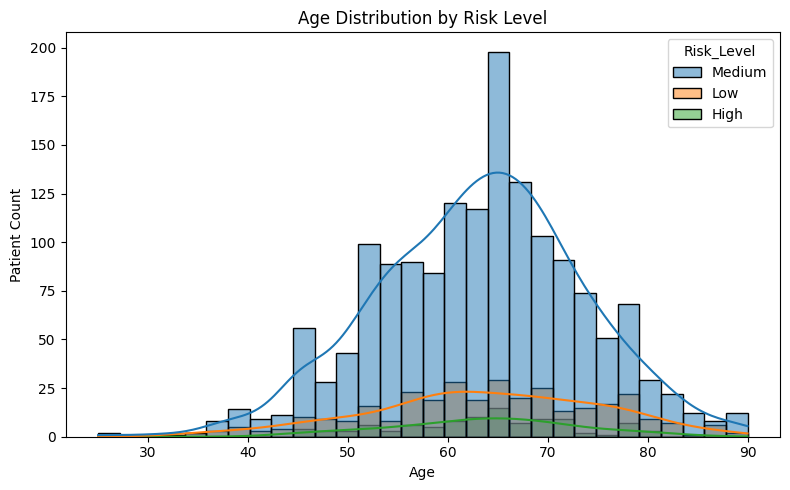

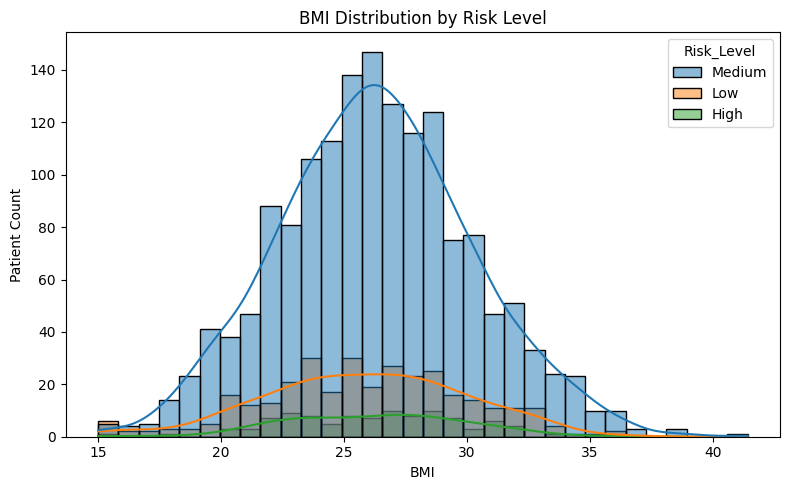

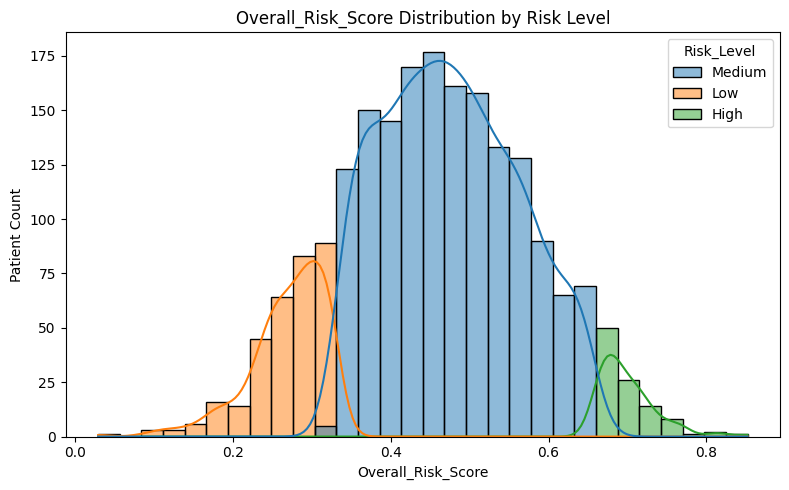

In [20]:
numerical_cols = ['Age', 'BMI', 'Overall_Risk_Score']

for col in numerical_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=col, hue='Risk_Level', kde=True)

    plt.title(f'{col} Distribution by Risk Level')
    plt.xlabel(col)
    plt.ylabel('Patient Count')
    plt.tight_layout()
    plt.show()

                        Age       BMI  Overall_Risk_Score
Age                 1.00000 -0.008940           -0.036230
BMI                -0.00894  1.000000            0.037164
Overall_Risk_Score -0.03623  0.037164            1.000000


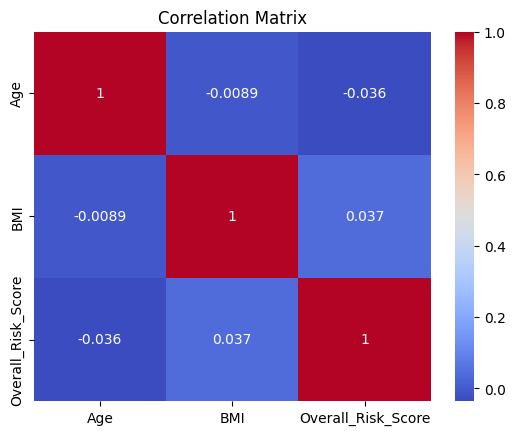

In [21]:
numerical_cols = ['Age', 'BMI', 'Overall_Risk_Score']

corr = df[numerical_cols].corr()

print(corr)

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [22]:
pd.crosstab(
    [df['Smoking'], df['Obesity']],
    df['Risk_Level'],
    normalize='index'
).round(2) * 100

Risk_Level       High   Low  Medium
Smoking Obesity                    
0       0         0.0  67.0    33.0
        1         0.0  12.0    88.0
        2         0.0  42.0    58.0
        3         0.0  75.0    25.0
        4         0.0  39.0    61.0
...               ...   ...     ...
10      6        12.0   0.0    88.0
        7        14.0   0.0    86.0
        8        25.0   0.0    75.0
        9        13.0   0.0    87.0
        10       13.0   0.0    87.0

[120 rows x 3 columns]

Risk Level Mapping:
High = 0
Low = 1
Medium = 2

Correlation with Risk_Level:
Risk_Level                 1.000000
Smoking                    0.073742
Overall_Risk_Score         0.073507
Alcohol_Use                0.044370
Family_History             0.036425
Air_Pollution              0.032525
Occupational_Hazards       0.032289
Obesity                    0.031164
BMI                        0.025814
Cancer_Type_Lung           0.023203
Cancer_Type_Skin           0.019722
Diet_Salted_Processed      0.011165
Calcium_Intake             0.004696
Physical_Activity_Level   -0.006231
H_Pylori_Infection        -0.007508
Fruit_Veg_Intake          -0.009739
Gender                    -0.010672
Diet_Red_Meat             -0.014256
Cancer_Type_Colon         -0.015019
Age                       -0.021343
Physical_Activity         -0.022543
BRCA_Mutation             -0.025071
Cancer_Type_Prostate      -0.047217
Name: Risk_Level, dtype: float64


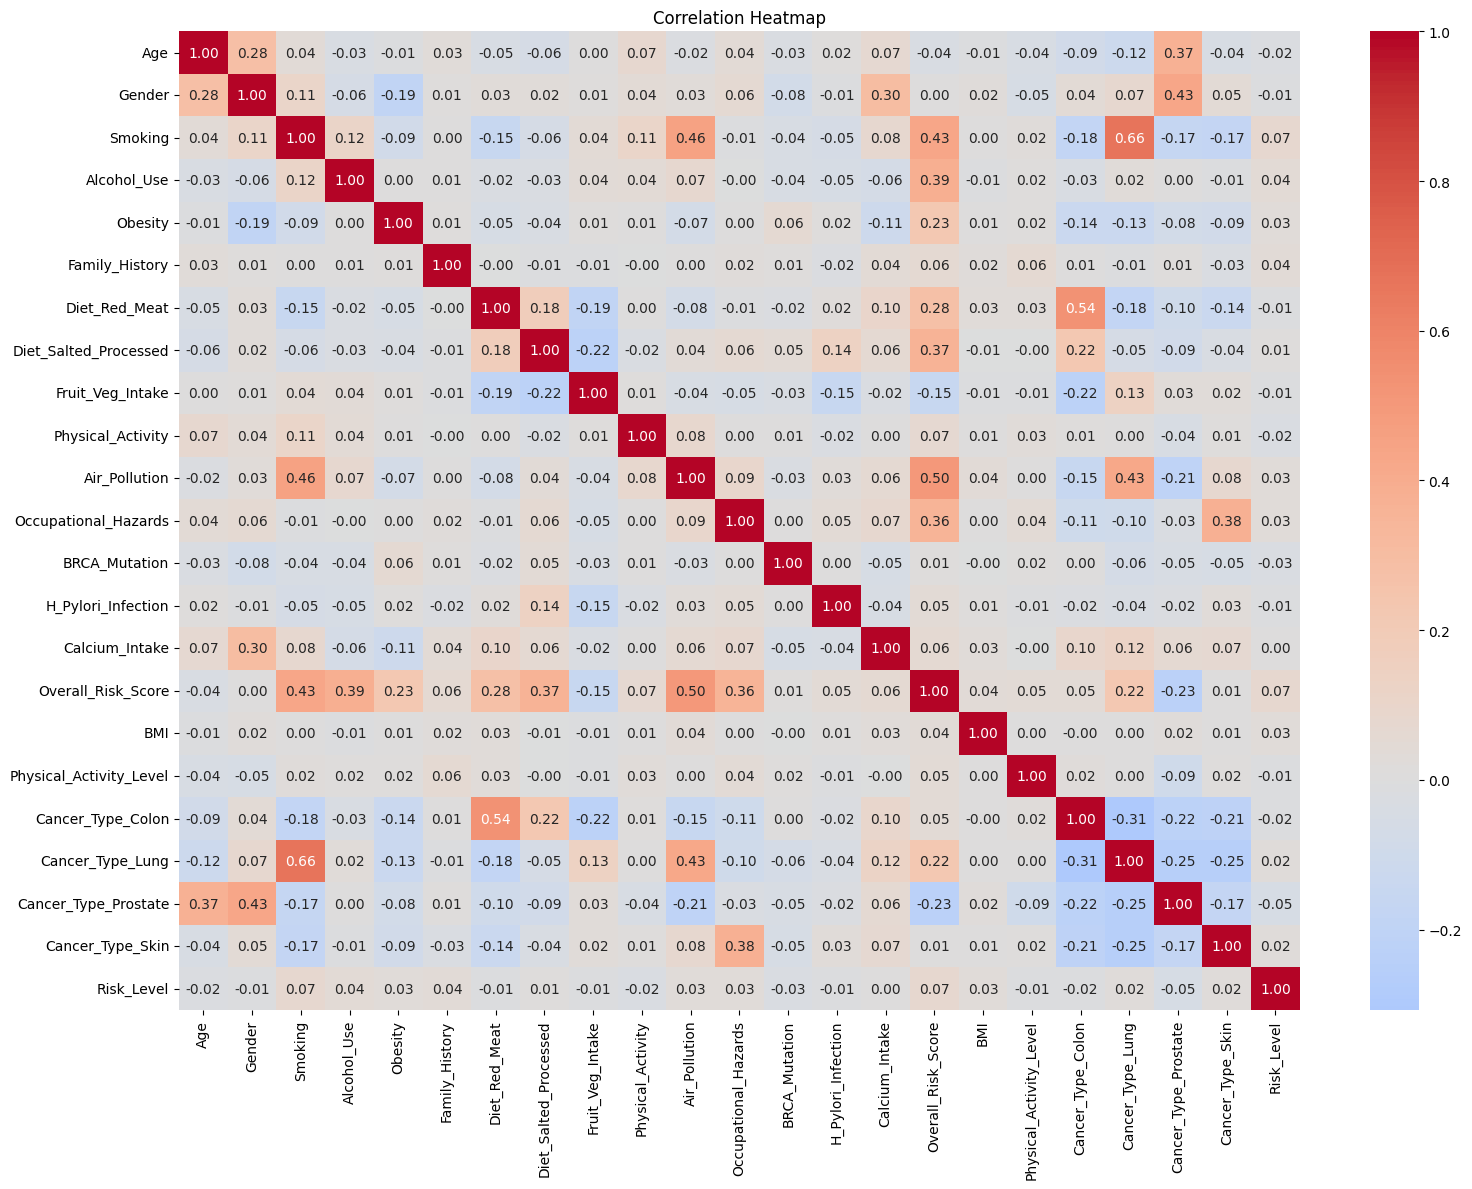

In [23]:
# 1. Drop Patient_ID
df_model = df.drop(columns=['Patient_ID']).copy()

# 2. Separate X and y
X = df_model.drop(columns=['Risk_Level'])
y = df_model['Risk_Level']

# 3. Label Encoding for target variable
le = LabelEncoder()
y = le.fit_transform(y)

print("Risk Level Mapping:")
for label, code in zip(le.classes_, le.transform(le.classes_)):
    print(label, "=", code)

# 4. Dummy/One-Hot Encoding for categorical X variables
X = pd.get_dummies(X, drop_first=True, dtype=int)

# 5. Create correlation dataset
correlation_df = X.copy()
correlation_df['Risk_Level'] = y

# 6. Correlation matrix
corr = correlation_df.corr()

print("\nCorrelation with Risk_Level:")
print(corr['Risk_Level'].sort_values(ascending=False))

# 7. Correlation heatmap
plt.figure(figsize=(16, 12))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

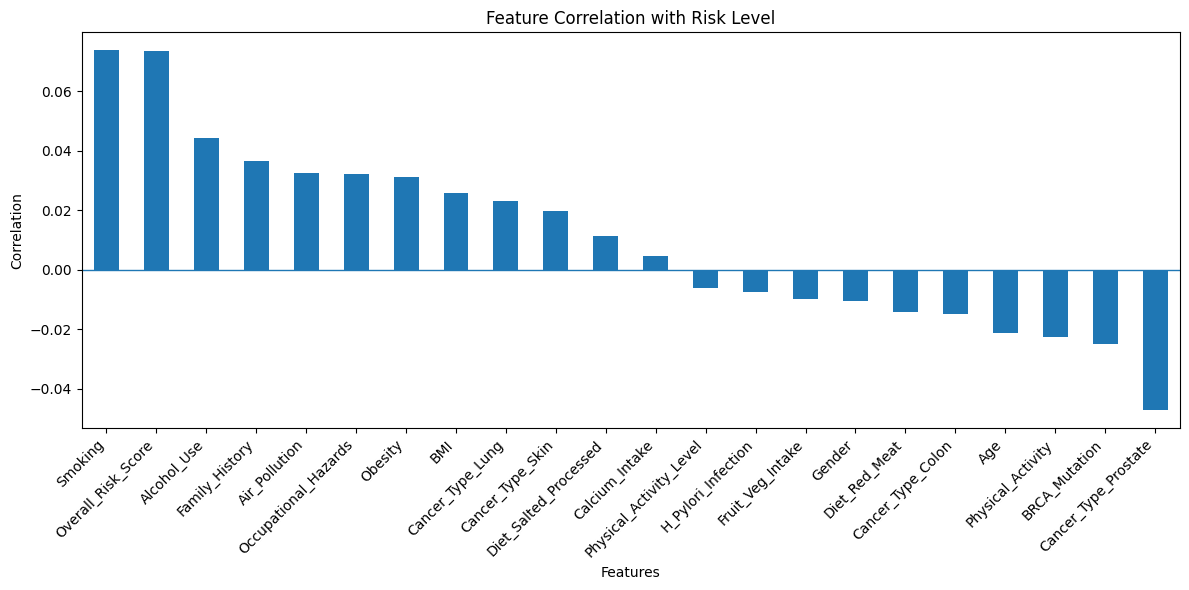

In [24]:
corr_with_target = corr['Risk_Level'].drop('Risk_Level').sort_values(ascending=False)

plt.figure(figsize=(12, 6))

corr_with_target.plot(kind='bar')

plt.title('Feature Correlation with Risk Level')
plt.xlabel('Features')
plt.ylabel('Correlation')
plt.xticks(rotation=45, ha='right')
plt.axhline(0, linewidth=1)
plt.tight_layout()
plt.show()